# Event log Gesetzentwurf Topic Embeddings

In [1]:
%load_ext autoreload
%autoreload 2
import pm4py
import pandas as pd
import ast

import helper
import plotting

In [ ]:
# load event log
event_log_berlin_full = pm4py.read_xes("./data-start/berlin-preprocessed-filtered-Gesetzgebung-with-Gesetzentwurf-allTime.xes")
event_log_bawue_full = pm4py.read_xes("./data-start/BaWue-preprocessed-filtered-Gesetzgebung-with-Gesetzentwurf-allTime.xes")
event_log_brandenburg_full = pm4py.read_xes("./data-start/Brandenburg-preprocessed-filtered-Gesetzgebung-with-Gesetzentwurf-allTime.xes")

event_logs = [
    event_log_berlin_full,
    event_log_bawue_full,
    event_log_brandenburg_full
]

parsing log, completed traces ::   0%|          | 0/157 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1813 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/132 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1465 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1410 [00:00<?, ?it/s]

In [3]:
dfs_with_embeddings = []

for df in event_logs:
    # Pick first event of each trace (is always the Gesetzentwurf event) to represent the trace
    trace_df = df.groupby('case:concept:name').first().reset_index()

    # Prepare texts for embeddings
    texts_for_embeddings = [
        f"Dieser Text beschreibt einen Gesetzesentwurf. Titel: {row['Titel']} "
        f"Abstrakt: {row['Abstract']} "
        f"Deskriptoren: {', '.join(ast.literal_eval(row['case:VorgangsDeskriptoren']))}"
        for row in trace_df.to_dict(orient='records')
    ]

    # Call embeddings API
    embeddings = helper.get_embeddings(texts_for_embeddings)

    # Add embeddings to trace_df
    trace_df['case:embedding'] = embeddings

    # Merge embeddings back to original DataFrame
    df = df.merge(trace_df[['case:concept:name', 'case:embedding']], on='case:concept:name', how='left')

    # ToDo: adjust so that the filenames are better (right now you have to manually remove or add -allTime for example)
    df.to_csv("./data-csv/" + df['case:DHerkL'].iloc[0] + "-with-embeddings-allTime.csv", index=False)
    dfs_with_embeddings.append(df)


KeyboardInterrupt: 

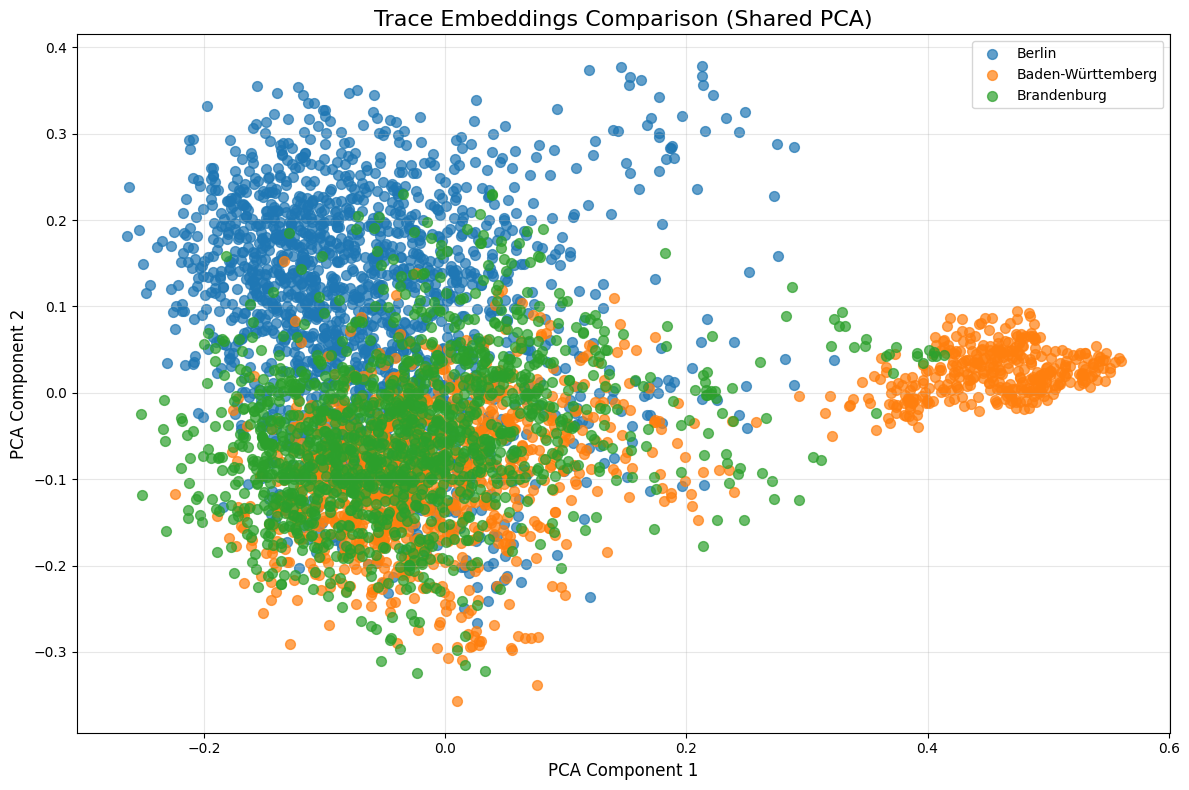

In [ ]:
plotting.plot_trace_embeddings(dfs_with_embeddings, names=["Berlin", "Baden-Württemberg", "Brandenburg"])